# Residual diagnostics and variable transformations

A linear regression model is only trustworthy if its assumptions hold. For the errors $\varepsilon_i$ we assume that:

1. they have **expected value zero** (the model has the right functional form);
2. they have **constant variance** (homoscedasticity);
3. they are **normally distributed**;
4. they are **independent** of each other.

Since the errors are not observable, we check these assumptions on the residuals $r_i = y_i - \hat y_i$. The helper `diagnostic_plots` (in `diagnostics.py`) draws the four standard plots:

| Plot | Checks | What a problem looks like |
|---|---|---|
| Residuals vs fitted (Tukey-Anscombe) | assumption 1 | the smoother bends away from zero |
| Normal Q-Q | assumption 3 | points leave the diagonal |
| Scale-location | assumption 2 | the smoother increases or decreases |
| Residuals vs leverage | influential points | points beyond the Cook's distance lines |

Smoothers always wiggle a bit, even when the model is correct. To judge whether a pattern is real, the plots also show in grey the smoothers of residuals **simulated from a correct model**: if the red curve stays inside the grey band, the pattern can be explained by chance.

The notebook first trains the eye on simulated data, where we know exactly which assumption is broken, and then applies the same checks to real datasets, using variable transformations to fix the problems we find.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import warnings

from diagnostics import diagnostic_plots

warnings.filterwarnings("ignore", message="kurtosistest only valid")
plt.rcParams["figure.dpi"] = 100

## 1. Learning to read the plots on simulated data

We generate four datasets with $n = 100$ points, $x = 0, 1, \dots, 99$ and standard normal noise $z_i$:

| Case | True model | Violated assumption |
|---|---|---|
| A | $y = 2 + x + z$ | none |
| B | $y = 2 + x + x \cdot z$ | constant variance (strongly) |
| C | $y = 2 + x + (1 + x/100) \cdot z$ | constant variance (mildly) |
| D | $y = \cos(2\pi x / 100) + z$ | linearity |

In every case we fit the same straight line $y = \beta_0 + \beta_1 x$.

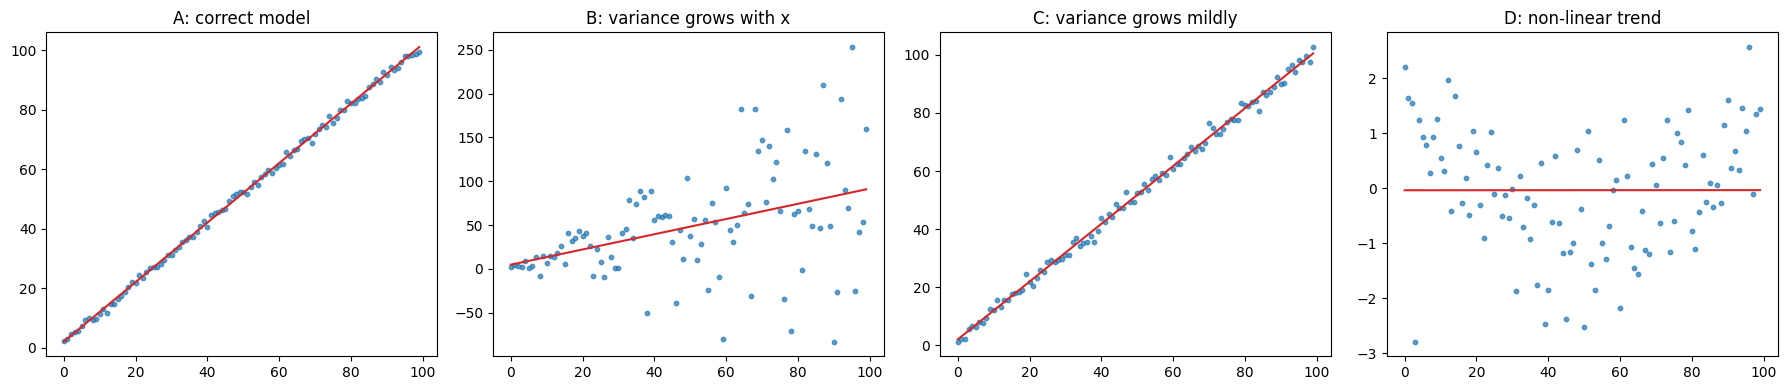

In [2]:
rng = np.random.default_rng(0)
n = 100
x = pd.Series(np.arange(n, dtype=float), name="x")
z = lambda: rng.normal(size=n)

simulated = {
    "A: correct model": 2 + x + z(),
    "B: variance grows with x": 2 + x + z() * x,
    "C: variance grows mildly": 2 + x + z() * (1 + x / n),
    "D: non-linear trend": np.cos(x * np.pi / (n / 2)) + z(),
}

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
sim_fits = {}
for ax, (name, y) in zip(axes, simulated.items()):
    sim_fits[name] = sm.OLS(y, sm.add_constant(x)).fit()
    ax.scatter(x, y, s=10, alpha=0.7)
    ax.plot(x, sim_fits[name].fittedvalues, color="tab:red")
    ax.set_title(name)
fig.tight_layout()
plt.show()

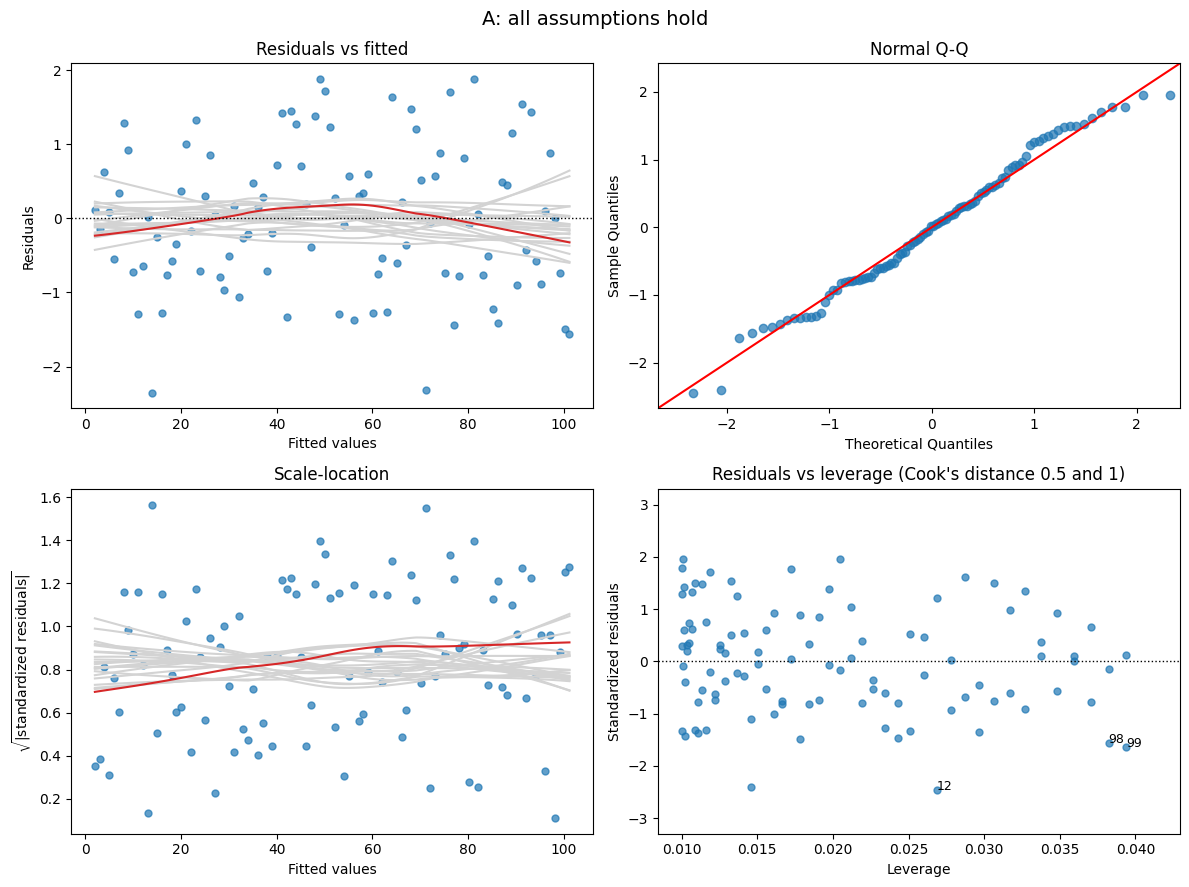

In [3]:
diagnostic_plots(sim_fits["A: correct model"], title="A: all assumptions hold")

**Case A** is the reference: residuals scatter evenly around zero, the Q-Q plot follows the diagonal, the scale-location smoother is flat and no point stands out in the leverage plot. All smoothers lie within the grey band.

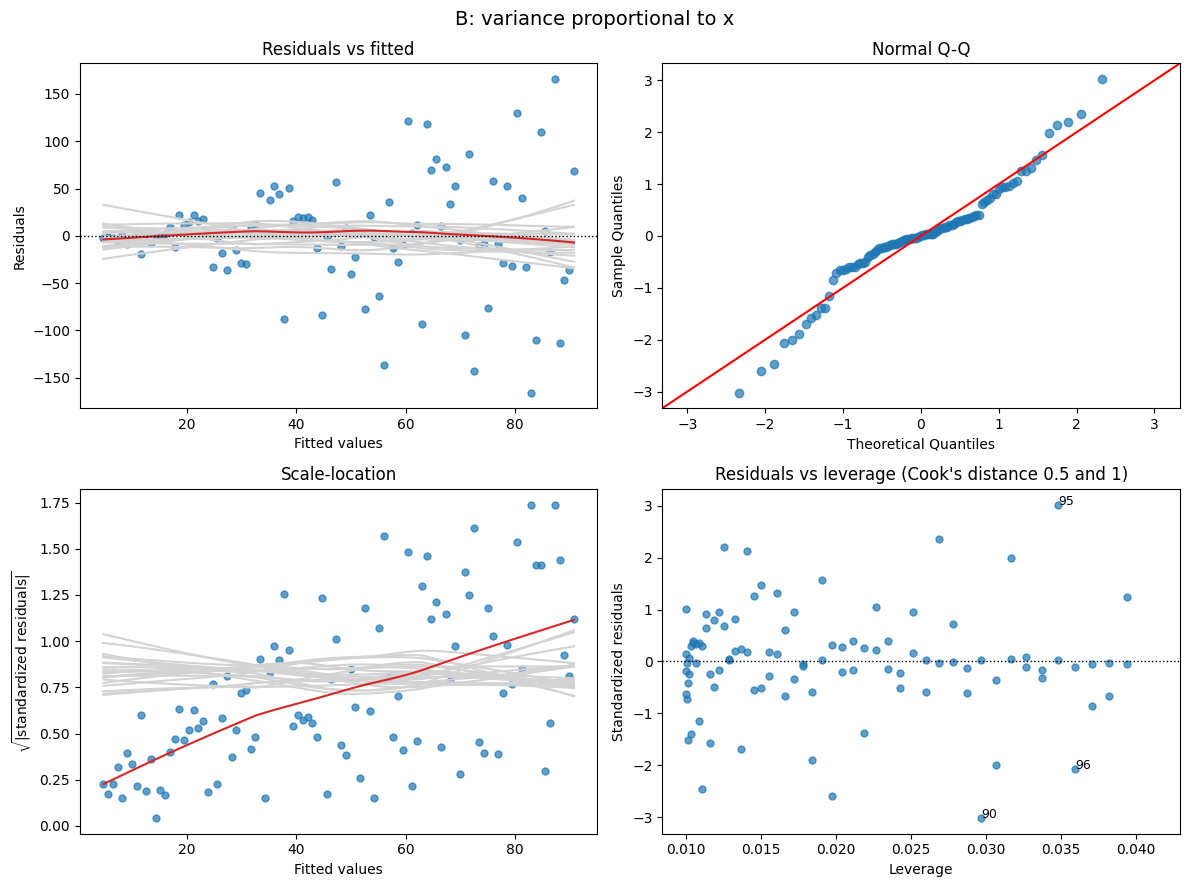

In [4]:
diagnostic_plots(sim_fits["B: variance grows with x"], title="B: variance proportional to x")

**Case B** shows the classic *funnel*: the spread of the residuals grows with the fitted values. The scale-location smoother rises steeply and leaves the grey band, so the constant-variance assumption is clearly violated. Because the large residuals all come from large $x$, the tails of the Q-Q plot also bend away from the line. The mean of the errors is still zero, so the estimated line itself is unbiased, but standard errors, tests and intervals are not reliable.

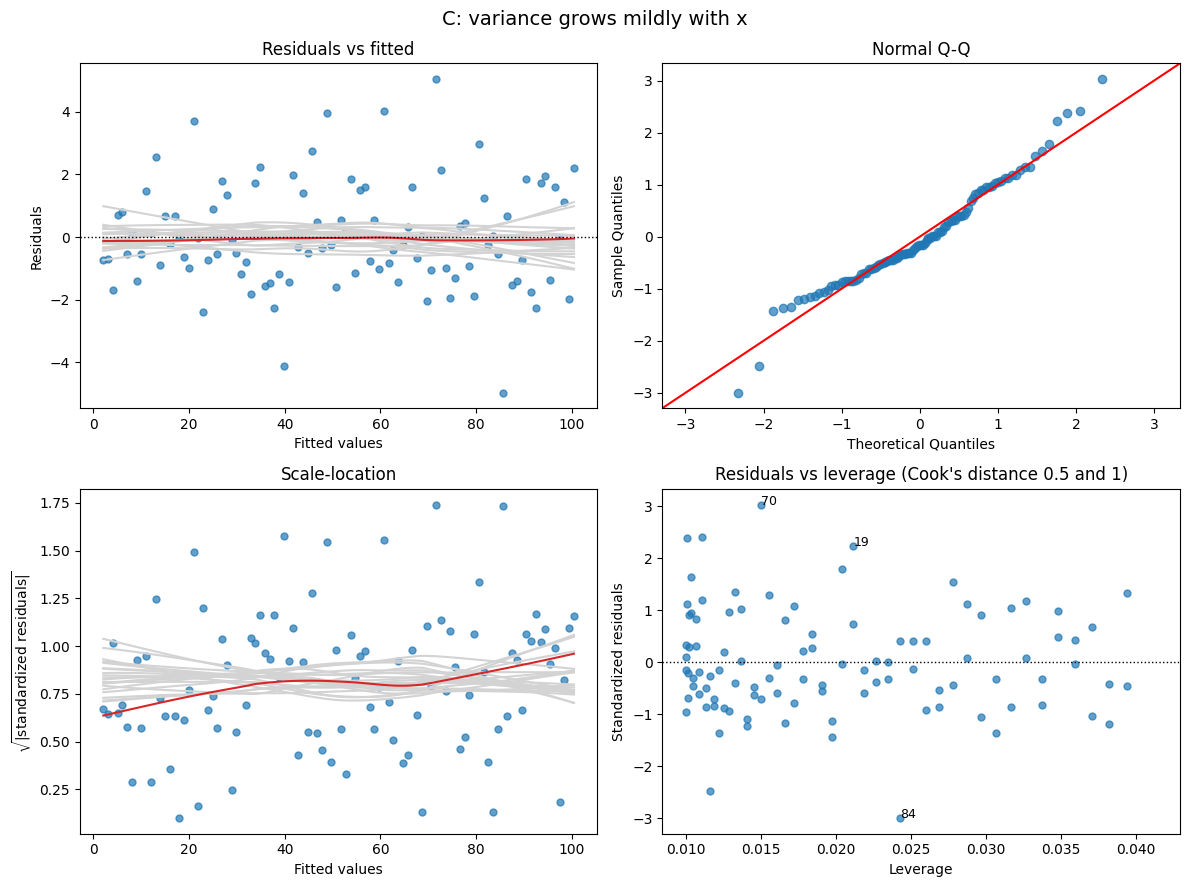

In [5]:
diagnostic_plots(sim_fits["C: variance grows mildly"], title="C: variance grows mildly with x")

**Case C** has the same kind of problem as B but much weaker: the error standard deviation only doubles from left to right. The scale-location smoother rises slightly but stays close to the band. With real data, a deviation this small would usually be tolerated.

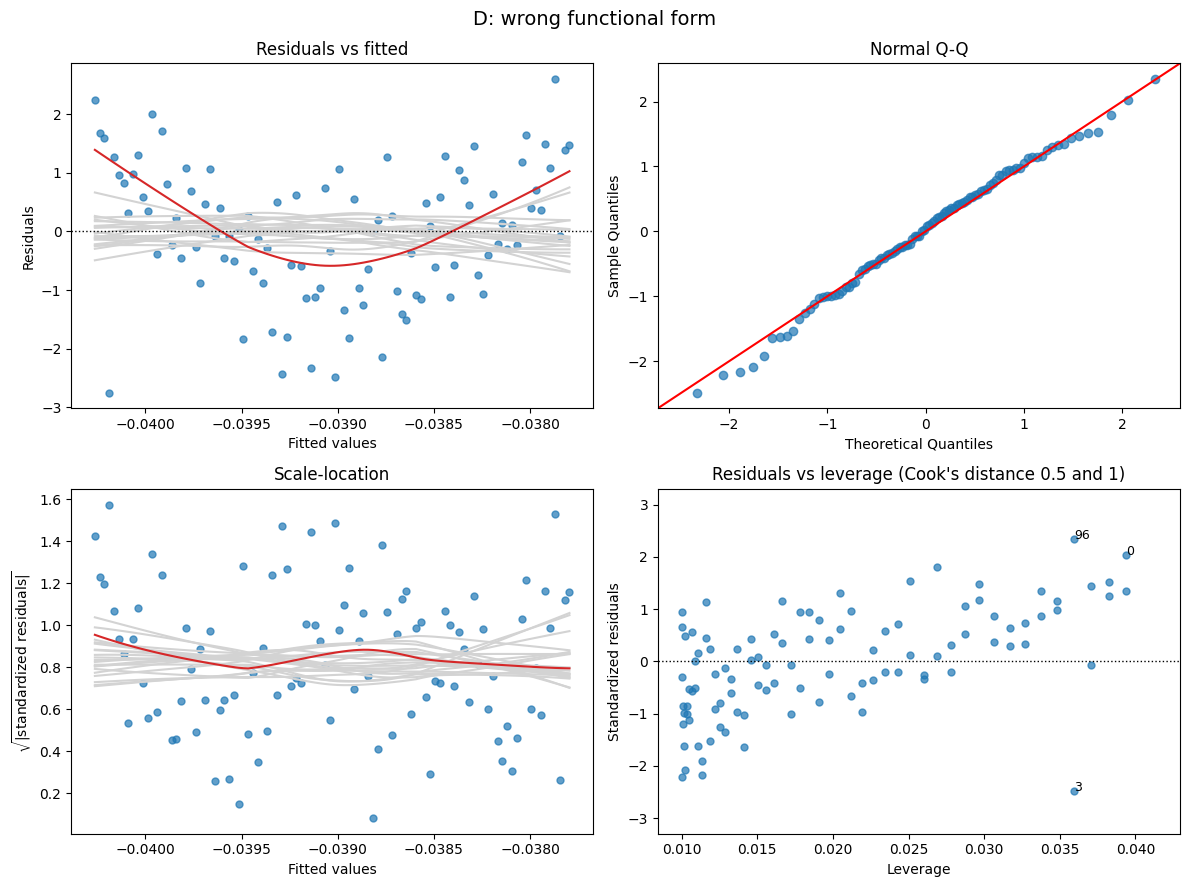

In [6]:
diagnostic_plots(sim_fits["D: non-linear trend"], title="D: wrong functional form")

**Case D** violates linearity: the Tukey-Anscombe smoother draws a wave (a cosine) that clearly leaves the grey band. When this happens, all other checks are secondary, because the residuals come from the wrong model. The fix is a different model: transform the variables or add terms.

## 2. Choosing a transformation: windmill power

We return to the windmill data (current produced vs wind speed) and compare three candidate models:

- **naive**: current ~ wind speed;
- **"first aid" log-log**: log(current) ~ log(wind speed), a common default when both variables are positive and skewed;
- **physics-based**: current ~ 1 / wind speed, since the current saturates at a maximum value.

In [7]:
windmill = pd.read_csv("data/windmill.csv")
speed, current = windmill["wind_speed"], windmill["current"]

wind_models = {
    "naive": sm.OLS(current, sm.add_constant(speed.rename("speed"))).fit(),
    "log-log": sm.OLS(np.log(current), sm.add_constant(np.log(speed).rename("log_speed"))).fit(),
    "reciprocal": sm.OLS(current, sm.add_constant((1 / speed).rename("inv_speed"))).fit(),
}
pd.DataFrame({name: {"R2": m.rsquared, "sigma_hat": np.sqrt(m.scale)} for name, m in wind_models.items()}).round(3)

,naive,log-log,reciprocal
R2,0.874,0.737,0.980
sigma_hat,0.236,0.354,0.094


The reciprocal model has the highest $R^2$, but the comparison is not entirely fair: the log-log model explains a different response (log(current)), so its $R^2$ and $\hat\sigma$ are on another scale. The residual plots give a more reliable comparison.

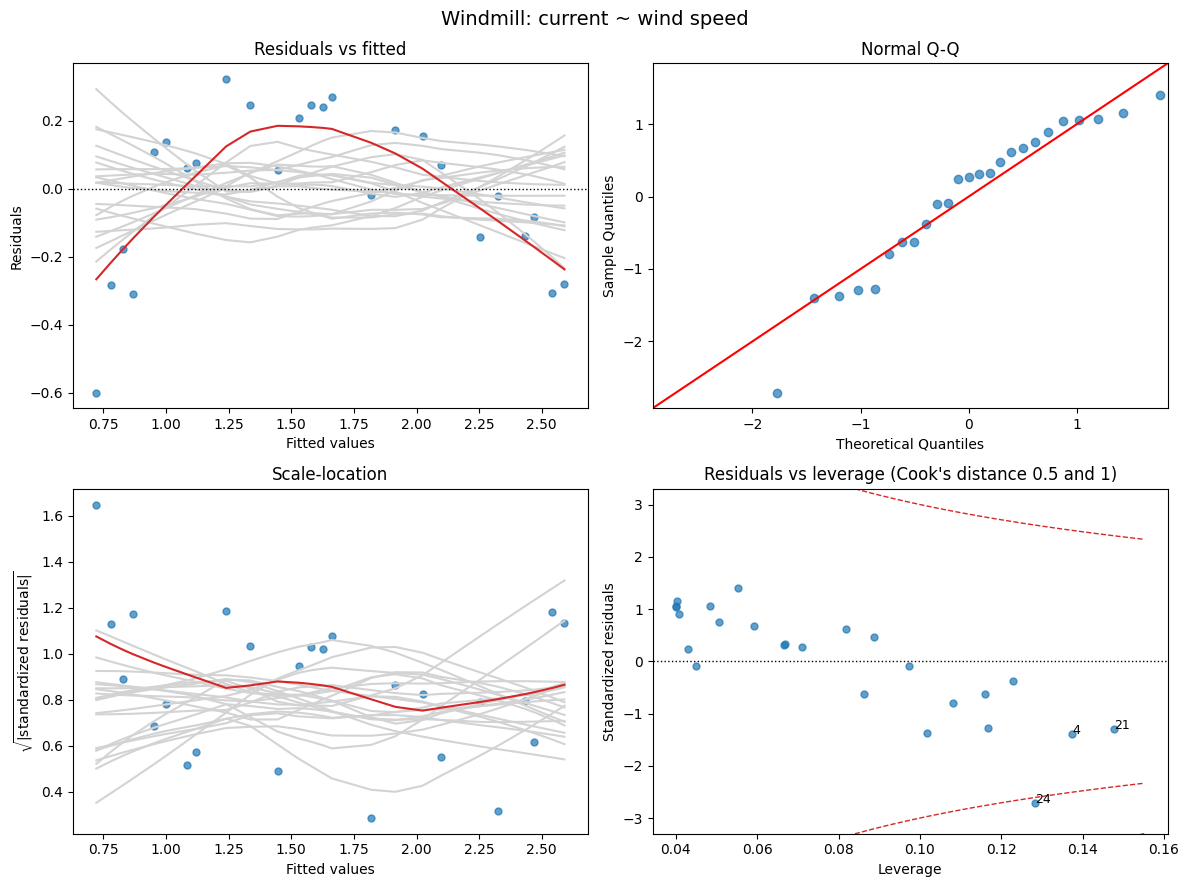

In [8]:
diagnostic_plots(wind_models["naive"], title="Windmill: current ~ wind speed")

The **naive model** has a pronounced banana shape in the Tukey-Anscombe plot, far outside the grey band: the straight line overestimates the current at both ends and underestimates it in the middle. The functional form is wrong.

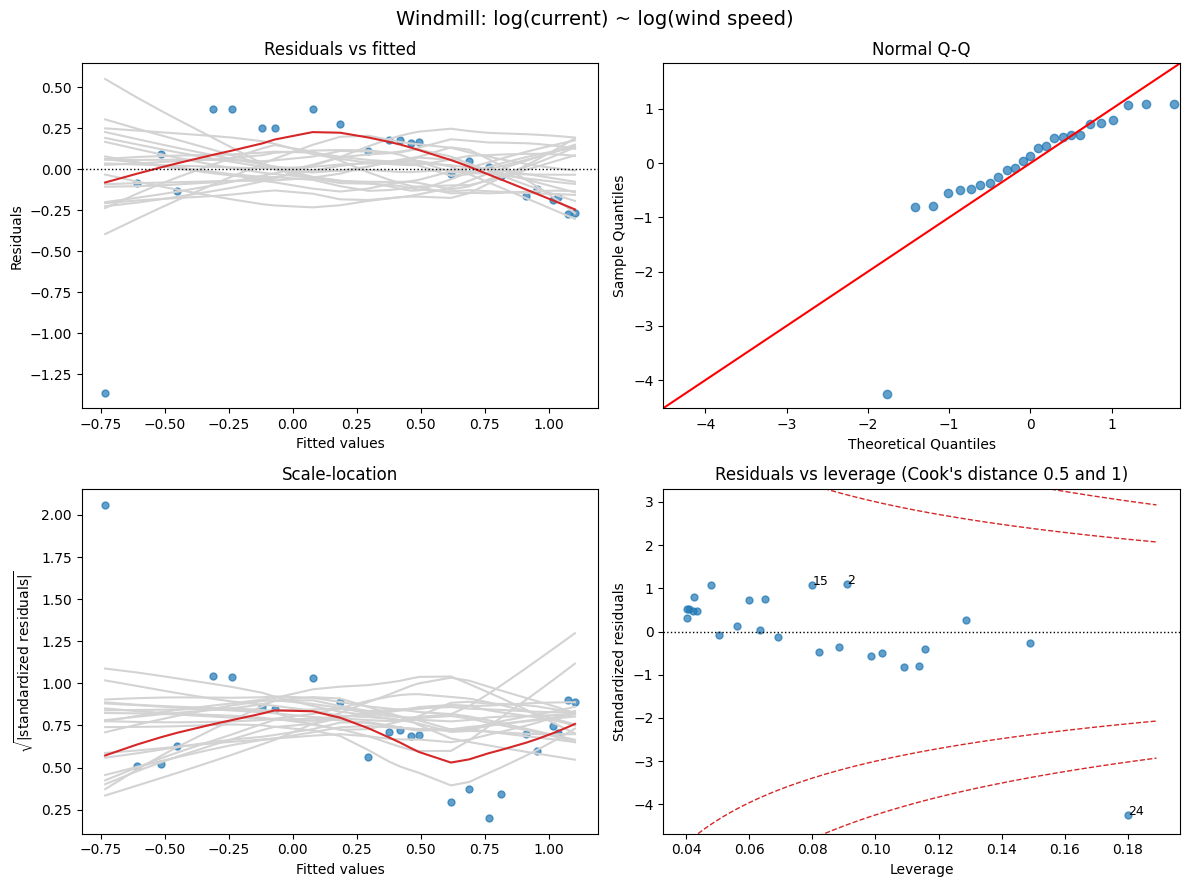

In [9]:
diagnostic_plots(wind_models["log-log"], title="Windmill: log(current) ~ log(wind speed)")

The **log-log model** is better but still curved. The lowest wind speed (observation 24) is badly fitted: it stands out in the Q-Q plot and has a large Cook's distance. The generic transformation does not capture the physics.

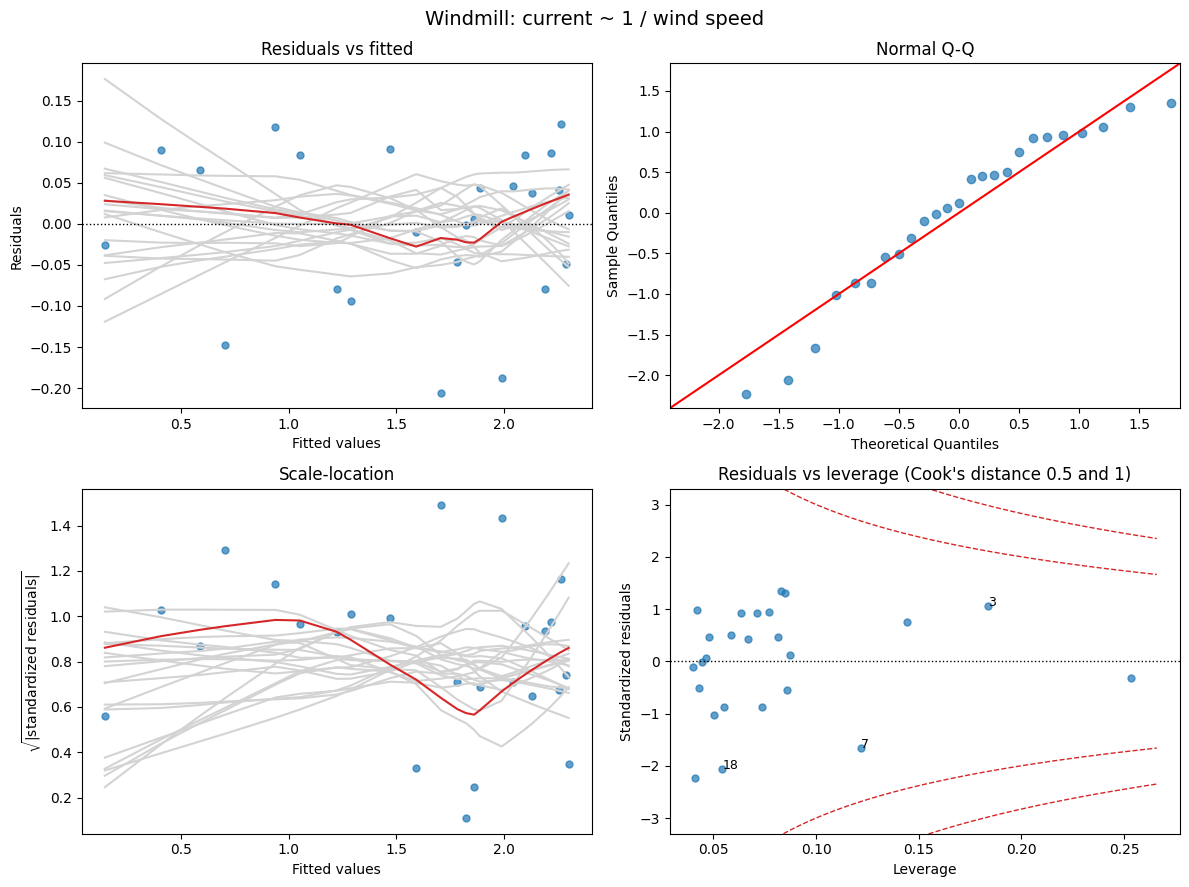

In [10]:
diagnostic_plots(wind_models["reciprocal"], title="Windmill: current ~ 1 / wind speed")

The **reciprocal model** shows no systematic pattern in the Tukey-Anscombe plot, the Q-Q plot is acceptable (slightly short-tailed, which is harmless for least squares) and no point is influential. The dip in the scale-location smoother is caused by three small residuals and does not indicate a trend in the variance.

**Takeaway:** domain knowledge often suggests a better transformation than generic defaults, and the residual plots are the tool to decide between candidates.

## 3. Spotting an outlier: Forbes' boiling point data

Boiling point of water vs $100 \cdot \log(\text{pressure})$, the model already used in the simple regression notebook.

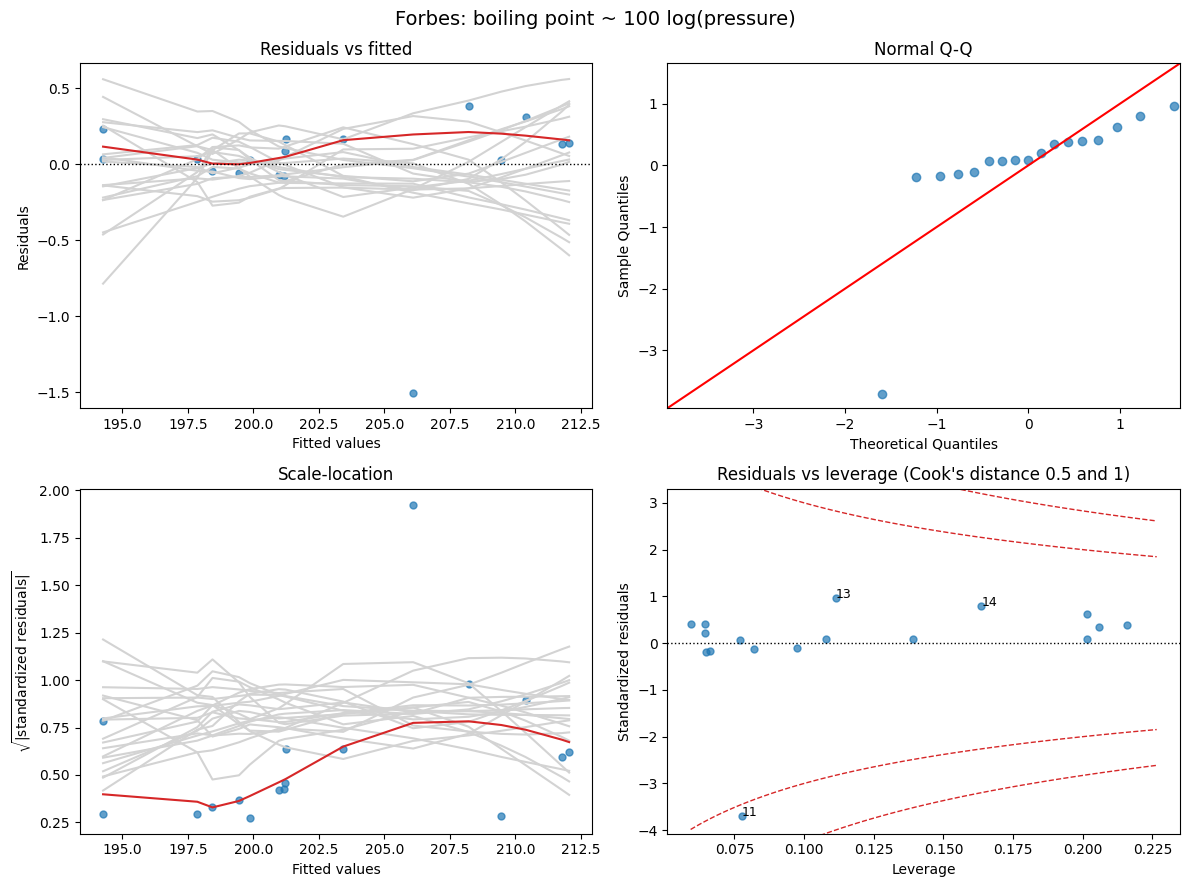

In [11]:
forbes = pd.read_csv("data/Forbes.csv")
forbes["x"] = 100 * np.log(forbes["pressure"])
forbes_fit = sm.OLS(forbes["y"], sm.add_constant(forbes[["x"]])).fit()
diagnostic_plots(forbes_fit, title="Forbes: boiling point ~ 100 log(pressure)")

Observation 11 dominates every plot: it falls far from the Q-Q line, inflates the scale-location smoother and has a Cook's distance above 0.5. Removing it (after checking that it really is a faulty measurement) gives a model with residual standard error three times smaller.

The **independence** assumption cannot be checked here: we do not know the order in which the measurements were taken. If they were collected over time, residuals of consecutive measurements could be correlated, and we would need to plot the residuals against time.

## 4. Rainfall and runoff: a log-log model

Rainfall volume and runoff volume (both in m³) measured at a road site during 15 rain events.

In [12]:
runoff = pd.DataFrame({
    "rainfall": [5, 12, 14, 17, 23, 30, 40, 47, 55, 67, 72, 81, 96, 112, 127],
    "runoff": [4, 10, 13, 15, 15, 25, 27, 46, 38, 46, 53, 70, 82, 99, 100],
})
lin_fit = sm.OLS(runoff["runoff"], sm.add_constant(runoff[["rainfall"]])).fit()
print(lin_fit.summary().tables[1])
print(f"R-squared: {lin_fit.rsquared:.3f}")

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.1283      2.368     -0.477      0.642      -6.244       3.987
rainfall       0.8270      0.037     22.642      0.000       0.748       0.906
R-squared: 0.975


At first sight the linear model looks excellent: $R^2 \approx 0.98$ and a highly significant slope.

- The slope $\hat\beta_1 \approx 0.83$ means that about 83% of the rain runs off. Its 95% confidence interval lies entirely below 1, so we can say with confidence that part of the rain does not reach the drainage: it evaporates or seeps into the ground.
- The intercept is negative (−1.1) and not significant. Taken literally, it predicts a negative runoff with no rain, which is impossible. There are no observations near zero, so the intercept is an extrapolation anyway.

Let us predict the runoff for a rainfall of 50 m³ and look at the residuals.

In [13]:
new = pd.DataFrame({"const": 1.0, "rainfall": [50]})
lin_fit.get_prediction(new).summary_frame(alpha=0.05).round(2)

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,40.22,1.36,37.29,43.15,28.53,51.92


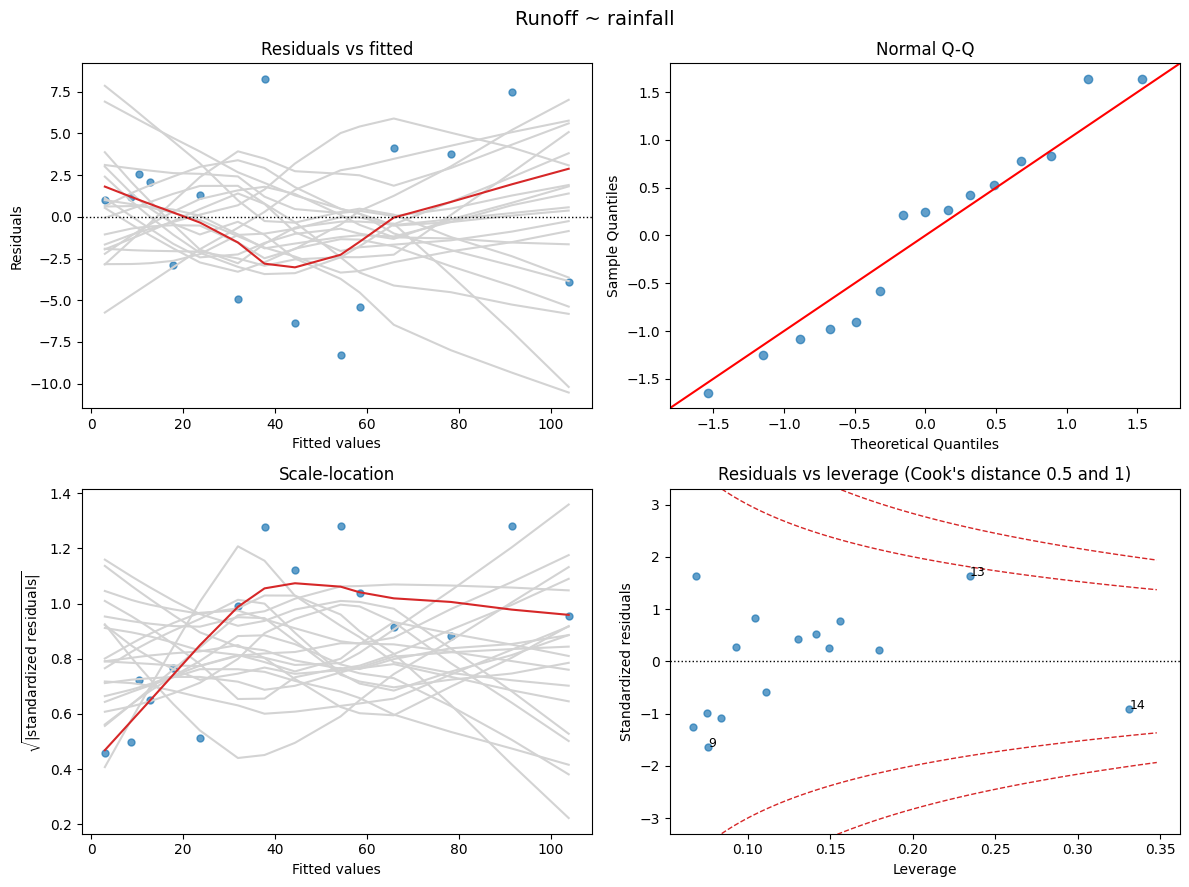

In [14]:
diagnostic_plots(lin_fit, title="Runoff ~ rainfall")

With only 15 points the smoothers wiggle a lot, and they stay inside the grey bands: the residuals give no strong evidence against the linear model. Still, the model has two practical flaws: it can predict negative runoff for small rainfalls, and it assumes the same uncertainty for a light shower and for a storm. For positive quantities whose variability grows with their size, a log-log model is the natural alternative:

$$\log(\text{runoff}) = \beta_0 + \beta_1 \log(\text{rainfall}) + \varepsilon \quad\Longleftrightarrow\quad \text{runoff} = e^{\beta_0} \cdot \text{rainfall}^{\beta_1} \cdot e^{\varepsilon}$$

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1837      0.138     -1.331      0.206      -0.482       0.115
rainfall       0.9892      0.037     26.908      0.000       0.910       1.069


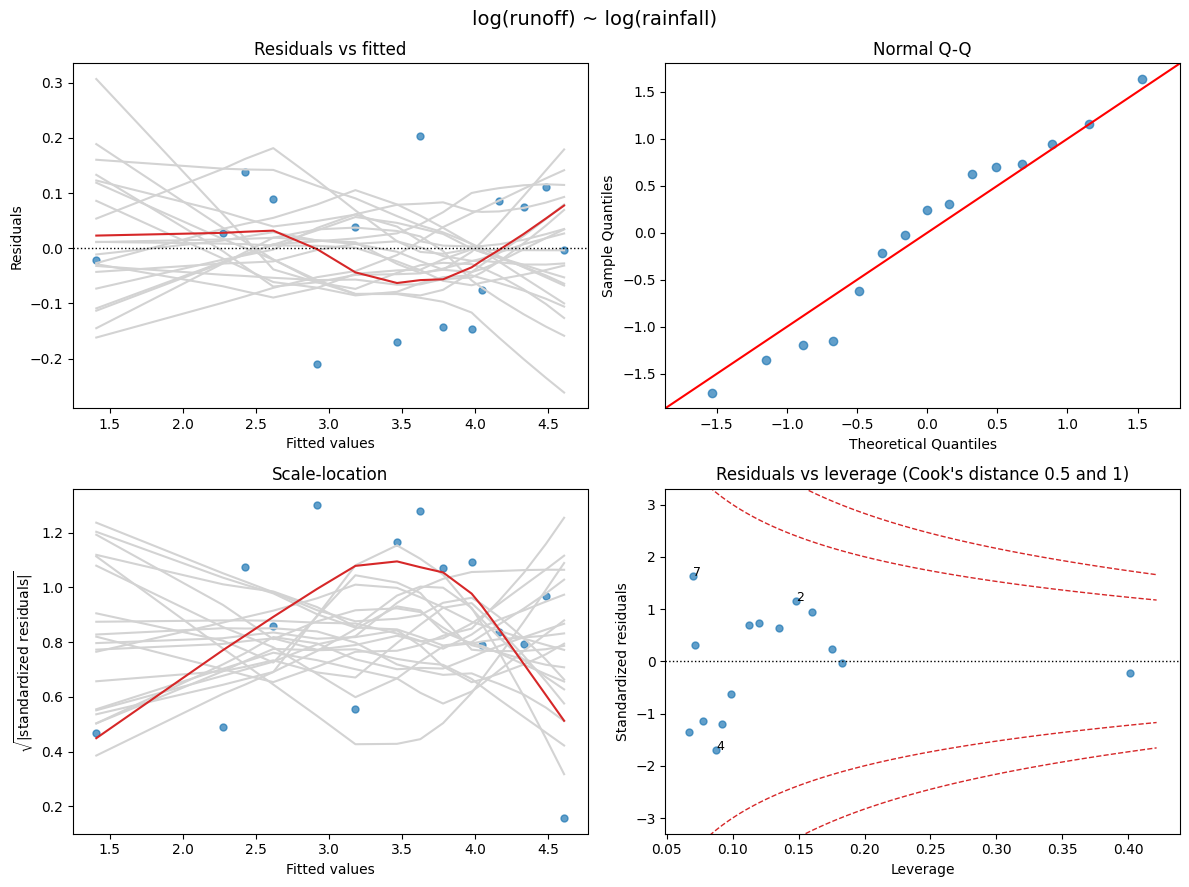

In [15]:
log_fit = sm.OLS(np.log(runoff["runoff"]), sm.add_constant(np.log(runoff[["rainfall"]]))).fit()
print(log_fit.summary().tables[1])
diagnostic_plots(log_fit, title="log(runoff) ~ log(rainfall)")

The residuals of the log-log model are just as acceptable. The slope is now an **elasticity**: a 1% increase in rainfall leads to a 0.99% increase in runoff. Its confidence interval contains 1, so runoff is simply **proportional** to rainfall, with factor $e^{\hat\beta_0} \approx 0.83$: the same 83% found by the linear model, now without a meaningless intercept.

Back on the original scale, the log-log model gives a curve that is always positive and a prediction band that widens with the rainfall, as the data suggest:

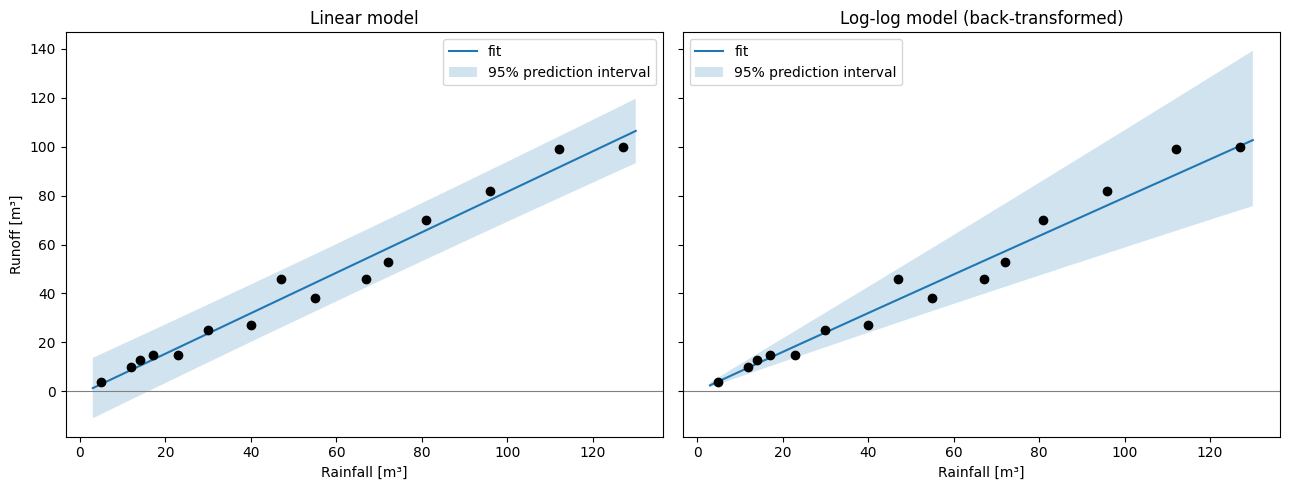

In [16]:
grid = pd.DataFrame({"const": 1.0, "rainfall": np.linspace(3, 130, 200)})
lin_pred = lin_fit.get_prediction(grid).summary_frame(alpha=0.05)
log_grid = grid.assign(rainfall=np.log(grid["rainfall"]))
log_pred = np.exp(log_fit.get_prediction(log_grid).summary_frame(alpha=0.05))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, pred, title in [(axes[0], lin_pred, "Linear model"), (axes[1], log_pred, "Log-log model (back-transformed)")]:
    ax.scatter(runoff["rainfall"], runoff["runoff"], color="black", zorder=3)
    ax.plot(grid["rainfall"], pred["mean"], color="tab:blue", label="fit")
    ax.fill_between(grid["rainfall"], pred["obs_ci_lower"], pred["obs_ci_upper"], alpha=0.2, label="95% prediction interval")
    ax.axhline(0, color="grey", lw=0.8)
    ax.set(title=title, xlabel="Rainfall [m³]")
    ax.legend()
axes[0].set_ylabel("Runoff [m³]")
fig.tight_layout()
plt.show()

## 5. Exponential decay: bacteria exposed to X-rays

Marine bacteria were exposed to X-rays for 15 consecutive intervals of 6 minutes; after each interval the number of surviving bacteria (in hundreds) was counted. The count for interval 5 is missing.

If a constant **proportion** of the bacteria is killed in every interval, the count decays exponentially:

$$N_t = N_0 \cdot q^t \quad\Longrightarrow\quad \log N_t = \log N_0 + t \log q ,$$

so a linear model on $\log N_t$ should fit well, and $q = e^{\beta_1}$ is the fraction of bacteria that survive each interval.

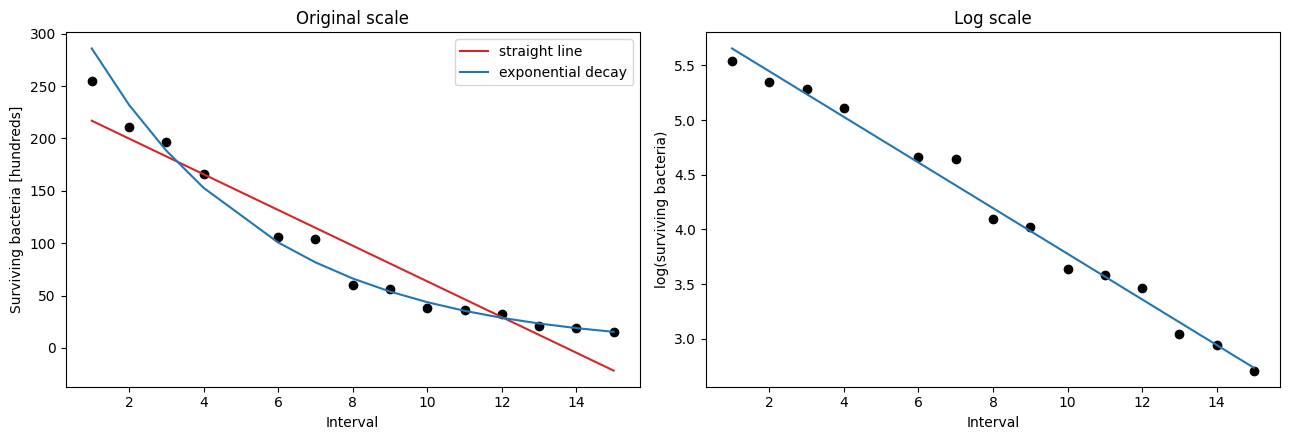

In [17]:
bacteria = pd.DataFrame({
    "interval": np.arange(1, 16),
    "survivors": [255, 211, 197, 166, np.nan, 106, 104, 60, 56, 38, 36, 32, 21, 19, 15],
})
observed = bacteria.dropna()

naive_fit = sm.OLS(observed["survivors"], sm.add_constant(observed[["interval"]])).fit()
decay_fit = sm.OLS(np.log(observed["survivors"]), sm.add_constant(observed[["interval"]])).fit()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
ax1.scatter(observed["interval"], observed["survivors"], color="black")
ax1.plot(observed["interval"], naive_fit.fittedvalues, color="tab:red", label="straight line")
ax1.plot(observed["interval"], np.exp(decay_fit.fittedvalues), color="tab:blue", label="exponential decay")
ax1.set(xlabel="Interval", ylabel="Surviving bacteria [hundreds]", title="Original scale")
ax1.legend()
ax2.scatter(observed["interval"], np.log(observed["survivors"]), color="black")
ax2.plot(observed["interval"], decay_fit.fittedvalues, color="tab:blue")
ax2.set(xlabel="Interval", ylabel="log(surviving bacteria)", title="Log scale")
fig.tight_layout()
plt.show()

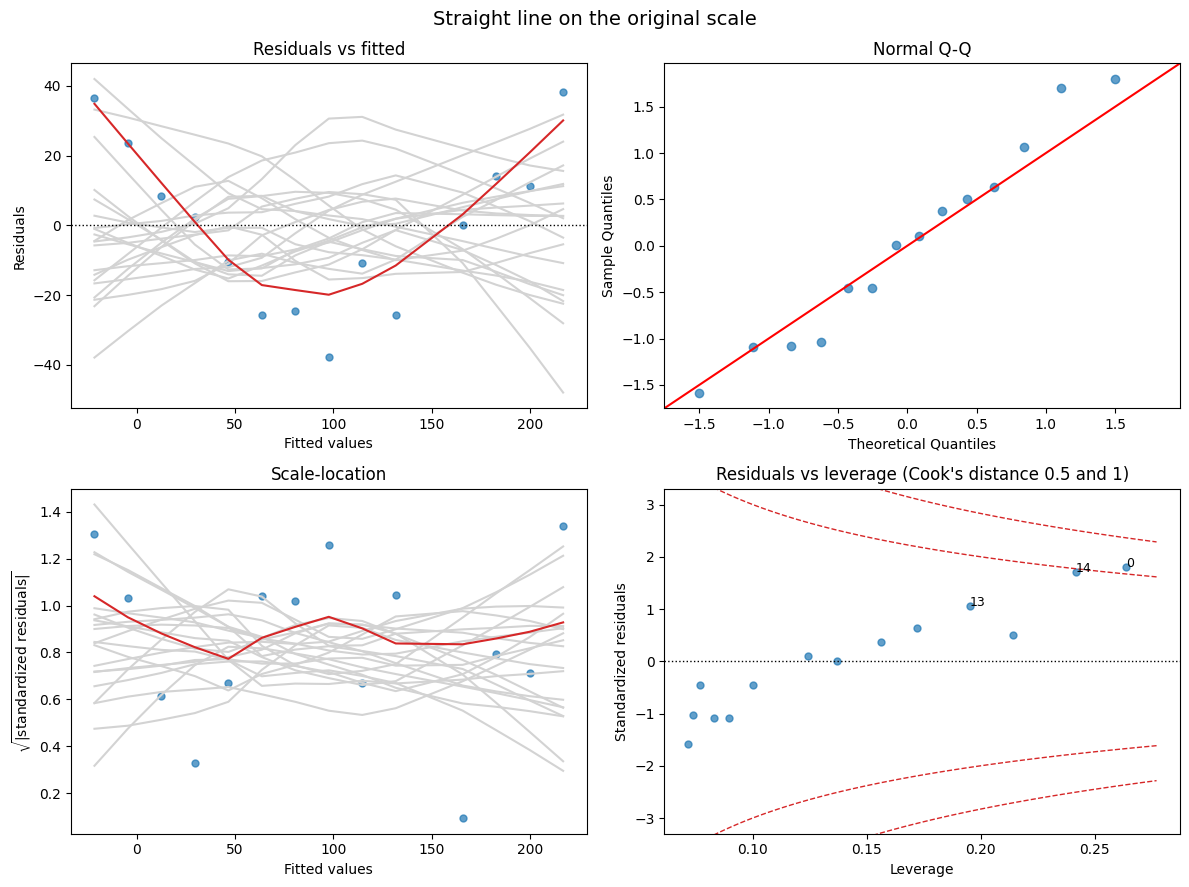

In [18]:
diagnostic_plots(naive_fit, title="Straight line on the original scale")

The straight line leaves a clear U-shaped pattern in the residuals: the functional form is wrong. (With the wrong model it makes little sense to study the Q-Q plot, since the residuals of the right model will be different.) On the log scale the points lie on a line, as theory predicts:

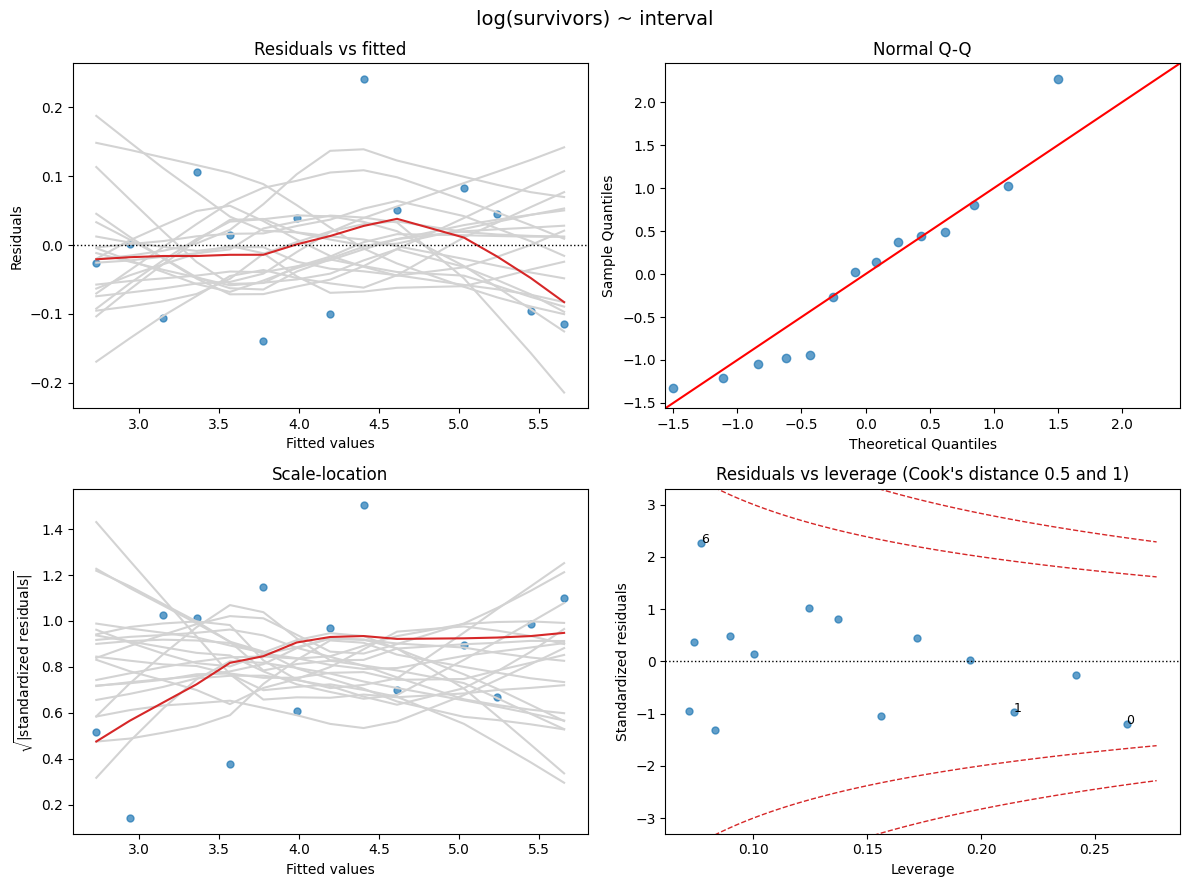

In [19]:
diagnostic_plots(decay_fit, title="log(survivors) ~ interval")

In [20]:
q = np.exp(decay_fit.params["interval"])
q_ci = np.exp(decay_fit.conf_int().loc["interval"])
n0 = np.exp(decay_fit.get_prediction(pd.DataFrame({"const": [1.0], "interval": [0]})).summary_frame(alpha=0.05))
n5 = np.exp(decay_fit.get_prediction(pd.DataFrame({"const": [1.0], "interval": [5]})).summary_frame(alpha=0.05))

print(f"Surviving fraction per interval: {q:.3f}  (95% CI {q_ci[0]:.3f} - {q_ci[1]:.3f})")
print(f"Killed per interval: {1 - q:.1%}")
print(f"Initial count N0: {n0['mean'].iloc[0]:.0f}  (95% CI {n0['mean_ci_lower'].iloc[0]:.0f} - {n0['mean_ci_upper'].iloc[0]:.0f})")
print(f"Missing count at interval 5: {n5['mean'].iloc[0]:.0f}  (95% prediction interval {n5['obs_ci_lower'].iloc[0]:.0f} - {n5['obs_ci_upper'].iloc[0]:.0f})")

Surviving fraction per interval: 0.812  (95% CI 0.800 - 0.824)
Killed per interval: 18.8%
Initial count N0: 352  (95% CI 307 - 404)
Missing count at interval 5: 124  (95% prediction interval 96 - 160)


The model gives a clear, physically meaningful answer: in each 6-minute interval about **19% of the bacteria are killed** and 81% survive, with a tight confidence interval. Since the intervals are computed on the log scale and then exponentiated, they are not symmetric around the estimate, as is natural for a positive quantity.

## Summary

- The four diagnostic plots, together with simulated reference bands, reveal violated assumptions that $R^2$ and p-values hide.
- **Non-linearity** is the most serious problem and must be fixed first, by transforming variables or changing the model.
- **Growing variance** for positive quantities is often cured by a log transformation of the response.
- Good transformations come from **domain knowledge**: a reciprocal for a saturating windmill, a log for exponential decay, a log-log power law for runoff.
- After a transformation, the coefficients often have a direct interpretation: an elasticity, or a constant rate of decay.